In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import linregress
from datetime import datetime

#### Filtragem para casos notificados

In [3]:
file_path = 'sinan_dourados_base.xlsx'
df_sinan = pd.read_excel(file_path)

# Filtrar Agravo
df_sinan = df_sinan[df_sinan['Doença'] == 'Chikungunya']

# Filtrar Município
df_sinan = df_sinan[df_sinan['Município da Residência'] == 'Dourados/MS']

# Excluir Linhas vazias
df_sinan = df_sinan.dropna(subset=['Semana Epidemiológica'])

# Filtrar Data dos Primeiros Sintomas
data_inicio = '01-01-2026'
data_fim = pd.to_datetime('today').normalize()

df_sinan = df_sinan.loc[df_sinan['Data dos Primeiros Sintomas'].between(data_inicio, data_fim)]

# Filtrar Semanas de Interesse
df_sinan = df_sinan[df_sinan['SE_NOT'].astype(str).str.startswith('2026')]

# Salvar os DataFrames filtrados em novos arquivos Excel
df_sinan.to_excel('sinan_dourados_notificados.xlsx', index=False)

print("Dados filtrados e salvos com sucesso!")

Dados filtrados e salvos com sucesso!


#### Contagem Notificados

In [5]:
df_sinan['Doença'].value_counts().reset_index(name = 'Total')

,Doença,Total
0,Chikungunya,8039


#### Filtragem para casos prováveis

In [6]:
file_path = 'sinan_dourados_notificados.xlsx'
df_provaveis = pd.read_excel(file_path)

# Filtrar Agravo
df_provaveis = df_provaveis[(df_provaveis['Classificação da Infecção'] != 'Descartado (Negativo)') & (df_provaveis['Classificação da Infecção'] != 'Dengue')]

# Salvar os DataFrames filtrados em novos arquivos Excel
df_provaveis.to_excel('sinan_dourados_provaveis.xlsx', index=False)

print("Dados filtrados e salvos com sucesso!")

Dados filtrados e salvos com sucesso!


#### Contagem Prováveis

In [7]:
df_provaveis['Doença'].value_counts().reset_index(name = 'Total')

,Doença,Total
0,Chikungunya,6297


#### Prováveis por semana

In [8]:
df_semanas = df_provaveis['SE'].value_counts().reset_index(name='Total')
df_semanas = df_semanas.sort_values(by='SE')
df_semanas.head(30)


,SE,Total
17,1,18
16,2,18
15,3,23
18,4,13
14,5,31
13,6,36
12,7,61
11,8,134
9,9,190
8,10,384


#### Notificados e Prováveis

In [9]:
pd.concat([df_sinan['Doença'].value_counts().reset_index(name= 'Total Notificados'), 
           df_provaveis['Doença'].value_counts().reset_index(name= 'Total Provaveis')], axis=1)

,Doença,Total Notificados,Doença,Total Provaveis
0,Chikungunya,8039,Chikungunya,6297


#### Gerar dataframe casos indígenas e não indígenas

In [10]:
file_path = 'sinan_dourados_provaveis.xlsx'
df_provaveis = pd.read_excel(file_path)

# Filtrar dados de interesse
df_urbano = df_provaveis[df_provaveis['Raça'] != 'Indígena']

# Filtrar dados de interesse 
df_indigena = df_provaveis[df_provaveis['Raça'] == 'Indígena']

# Salvar os DataFrames filtrados em novos arquivos Excel
df_urbano.to_excel('sinan_dourados_urbano.xlsx', index=False)
df_indigena.to_excel('sinan_dourados_indigena.xlsx', index=False)

print("Dados filtrados e salvos com sucesso!")

Dados filtrados e salvos com sucesso!


#### Total de casos - Indígenas e Não indígenas

In [11]:
pd.concat([df_indigena['Doença'].value_counts().reset_index(name= 'Indígenas'), 
           df_urbano['Doença'].value_counts().reset_index(name= 'Não Indígenas')], axis=1)

,Doença,Indígenas,Doença,Não Indígenas
0,Chikungunya,2442,Chikungunya,3855


#### Carregando file path

In [12]:
file_path_urbano = 'sinan_dourados_urbano.xlsx'
df_urbano = pd.read_excel(file_path_urbano)
file_path_indigena = 'sinan_dourados_indigena.xlsx'
df_indigena = pd.read_excel(file_path_indigena)

#### Análise área urbana - Casos por semana epidemiológica

In [14]:
df_semanas = df_urbano['SE'].value_counts().reset_index(name='Total')
df_semanas = df_semanas.sort_values(by='SE')
df_semanas.head(30)

,SE,Total
17,1,13
16,2,13
14,3,15
18,4,5
15,5,15
13,6,17
12,7,26
11,8,52
10,9,60
9,10,95


#### Previsão área urbana

ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA URBANA (14/05/2026)
Semanas no dataset: 19 (SE01–SE19)
Semanas fechadas  : 18

Fator nowcasting SE19: 1.15x (em aberto)
Fator nowcasting SE18: 1.00x

Rt (Wallinga-Lipsitch, janela 4 semanas)
Taxa de crescimento (r): -0.1306 por semana
Rt estimado            : 0.88

Total esperado de casos (taxa de ataque): 15800
Amplitude máxima (casos no pico): 40000 casos

Fase epidêmica detectada: DESCENDENTE/PLATÔ

Casos notificados      : 6297
Casos estimados (now.) : 6319
Rt (4 sem.)            : 0.88
Status                 : ESTABILIDADE
Fase epidêmica         : DESCENDENTE/PLATÔ
Pico projetado         : SE18 (em -1.0 semanas)
Casos no pico          : ~835 casos/semana
Duração total do surto : ~29 semanas
↑ Subida               : ~14 semanas (até SE18)
↓ Queda                : ~14 semanas (SE18 → SE32)
Fim estimado do surto  : SE32
Casos totais projetados: ~12290


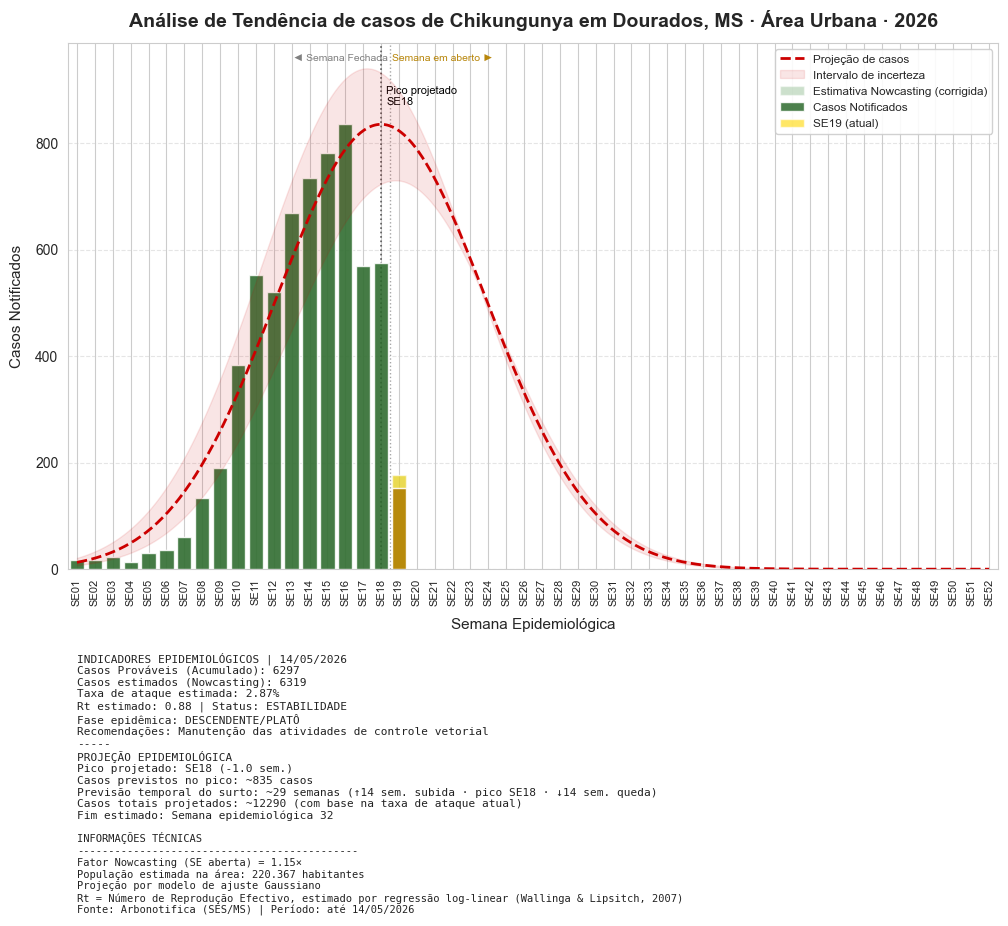

In [18]:
# 1. CARREGAMENTO DOS DADOS
df_urbano = pd.read_excel(file_path_urbano)
data_analise = datetime.now().strftime("%d/%m/%Y")

df_urbano['SE'] = pd.to_numeric(df_urbano['SE'], errors='coerce')
df_urbano = df_provaveis.dropna(subset=['SE'])

df_urbano = df_urbano.dropna(subset=['Semana Epidemiológica'])
df_urbano = df_urbano[~df_urbano['Semana Epidemiológica'].str.contains('53ª', na=False)]

# 2. AGRUPAMENTO E ORDENAÇÃO
contagem = df_urbano['SE'].value_counts().reset_index()
contagem.columns = ['num_semana', 'casos_brutos']

contagem = contagem.sort_values(by='num_semana').reset_index(drop=True)
contagem['tempo'] = contagem['num_semana']

N_SEMANAS = len(contagem)
SE_ATUAL  = contagem['num_semana'].iloc[-1]  
SE_FECHADAS = N_SEMANAS - 1                   

# 3. NOWCASTING — FATOR EMPÍRICO BASEADO NA SÉRIE HISTÓRICA
dia_da_semana = datetime.now().weekday()
DIA_ATUAL_NA_SEMANA = (dia_da_semana + 2) % 7
if DIA_ATUAL_NA_SEMANA == 0: DIA_ATUAL_NA_SEMANA = 7

# Fração da semana já transcorrida
fracao_semana = DIA_ATUAL_NA_SEMANA / 7.0

FATOR_ATRASO_SINAN = 1.05   # fator empírico médio considerando 1 dia de atraso de notificação

# TABELA DE REFERÊNCIA (FATOR_ATRASO_SINAN):
# 1d: 1.05 | 5d: 1.20 (Urbana) | 7d: 1.30 | 10d: 1.45 (Indígena)
# 15d: 1.65 | 21d: 1.90 | 30d: 2.20 | 60d: 3.00

fator_se_atual = (1 / fracao_semana) * FATOR_ATRASO_SINAN

# LIMITADOR (CAP): Garante que a SE atual não seja bizarramente maior que a anterior
fator_se_atual = min(fator_se_atual, 1.15) # Limite máximo de 60% de acréscimo sobre o parcial

FATOR_SE_ANTERIOR_1 = 1.00 #1.12   # SE13: 12% de subnotificação residual
FATOR_SE_ANTERIOR_2 = 1.00 #1.03   # SE12: 3% de subnotificação residual

fatores_correcao = {
    N_SEMANAS - 1: fator_se_atual,       
    N_SEMANAS - 2: FATOR_SE_ANTERIOR_1,  
    N_SEMANAS - 3: FATOR_SE_ANTERIOR_2,  
}

contagem['casos_corrigidos'] = contagem['casos_brutos'].astype(float)
for idx, fator in fatores_correcao.items():
    if 0 <= idx < N_SEMANAS:
        contagem.loc[idx, 'casos_corrigidos'] = (
            contagem.loc[idx, 'casos_brutos'] * fator
        )

df_final = contagem.copy()

# 4. ESTIMATIVA DO Rt — MÉTODO WALLINGA-LIPSITCH (JANELA DESLIZANTE)
INTERVALO_SERIAL_SEMANAS = 1.0   
JANELA_RT = min(4, SE_FECHADAS)  
y_janela = df_final['casos_corrigidos'].values[-(JANELA_RT + 1):-1] 
x_janela = np.arange(len(y_janela), dtype=float)
y_log = np.log(np.maximum(y_janela, 0.1))
slope, intercept, r_value, p_value, std_err = linregress(x_janela, y_log)
taxa_crescimento_r = slope
Rt = np.exp(taxa_crescimento_r * INTERVALO_SERIAL_SEMANAS)

# Taxa de crescimento semanal (razão simples, para exibição)
razao_crescimento = (df_final['casos_corrigidos'].iloc[-2] /
                     df_final['casos_corrigidos'].iloc[-3]
                     if df_final['casos_corrigidos'].iloc[-3] > 0 else 1.0)

# 5. PROJEÇÃO GAUSSIANA

CENARIO = 'urbana'
POPULACAO = 220_367 if CENARIO == 'urbana' else 23_000
TAXA_ATAQUE_HISTORICA = 0.51 if CENARIO == 'urbana' else 7.02

# 2. CÁLCULO DA TAXA DE ATAQUE EM TEMPO REAL (DINÂMICA)
casos_acumulados_corrigidos = df_final['casos_corrigidos'].sum()
taxa_ataque_notificada = (casos_acumulados_corrigidos / POPULACAO) * 100

# AJUSTE 1: Teto dinâmico mais folgado para Rt alto
TAXA_ATAQUE_MODELO = max(TAXA_ATAQUE_HISTORICA, taxa_ataque_notificada * 2.5)
CASOS_ESPERADOS_TOTAL = (TAXA_ATAQUE_MODELO / 100) * POPULACAO

def modelo_gaussiano(x, amplitude, x0, sigma):
    return amplitude * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

# AJUSTE 2: Incluímos a SE atual no ajuste para a curva "sentir" o peso da barra amarela
y_fit = df_final['casos_corrigidos'].values
x_fit = df_final['tempo'].values

if SE_FECHADAS >= 6:
    media_recente, media_anterior = np.mean(y_fit[-3:]), np.mean(y_fit[-6:-3])
    em_ascensao = media_recente > media_anterior
else:
    em_ascensao = True

fase_texto = "ASCENDENTE" if em_ascensao else "DESCENDENTE/PLATÔ"

# Bounds e Chutes mais agressivos
amplitude_min = max(y_fit) * 1.0  # Obriga a curva a cobrir a maior barra
amplitude_max = max(max(y_fit) * 2.0, 40000)
amplitude_p0  = np.clip(max(y_fit) * 1.5, amplitude_min + 1, amplitude_max - 1)

x0_min = float(SE_ATUAL - 1)
x0_max = float(SE_ATUAL + 15) if em_ascensao else float(SE_ATUAL + 2)
x0_p0 = np.clip(SE_ATUAL + 3, x0_min + 0.1, x0_max - 0.1)

sigma_min, sigma_max = 2.0, 10.0 # Curva mais larga para surtos urbanos
sigma_p0 = 5.0

try:
    popt, pcov = curve_fit(
        modelo_gaussiano, x_fit, y_fit,
        p0=[amplitude_p0, x0_p0, sigma_p0],
        bounds=([amplitude_min, x0_min, sigma_min], [amplitude_max, x0_max, sigma_max]),
        maxfev=50000
    )
    amplitude_fit, x0_fit, sigma_fit = popt
    perr = np.sqrt(np.diag(pcov))
    x_proj = np.linspace(1, 52, 500)
    y_proj = modelo_gaussiano(x_proj, *popt)
    
    fator_erro_amp = min(perr[0], amplitude_fit * 0.15)
    fator_erro_x0  = min(perr[1], 0.8)
    y_proj_sup = modelo_gaussiano(x_proj, amplitude_fit + fator_erro_amp, x0_fit - fator_erro_x0, sigma_fit)
    y_proj_inf = modelo_gaussiano(x_proj, max(amplitude_fit - fator_erro_amp, 0), x0_fit + fator_erro_x0, sigma_fit)

    if hasattr(np, 'trapezoid'): casos_totais_proj = np.trapezoid(y_proj, x_proj)
    else: casos_totais_proj = np.trapz(y_proj, x_proj)

# --- CÁLCULOS TÉCNICOS ---
    LIMIAR_SURTO = 0.05
    distancia_pico = x0_fit - SE_ATUAL
    casos_pico_estimado = amplitude_fit  
    fator_duracao = np.sqrt(2 * np.log(1 / LIMIAR_SURTO))
    se_inicio_surto = x0_fit - sigma_fit * fator_duracao
    se_fim_surto = x0_fit + sigma_fit * fator_duracao
    duracao_total = se_fim_surto - se_inicio_surto
    duracao_subida = x0_fit - se_inicio_surto
    duracao_queda = se_fim_surto - x0_fit
    
    ajuste_ok = True
except:
    ajuste_ok = False

# 6. CLASSIFICAÇÃO DO CENÁRIO EPIDEMIOLÓGICO
if Rt > 1.2:
    status_rt    = "ALTA"
    cor_status   = "#CC0000"
elif Rt > 1.0:
    status_rt    = "EM CRESCIMENTO"
    cor_status   = "#FF6600"
elif Rt > 0.8:
    status_rt    = "ESTABILIDADE"
    cor_status   = "#E6A817"
else:
    status_rt    = "DESACELERAÇÃO"
    cor_status   = "#2E8B57"

# DESDOBRAMENTOS
if Rt > 1.2:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 1.0:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 0.8:
    recomendação = "Manutenção das atividades de controle vetorial"
else:
    recomendação = "Monitoramento contínuo e manutenção das atividades de rotina"

# 7. VISUALIZAÇÃO
fig = plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Layout: gráfico principal (topo) + rodapé com indicadores
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

labels_ano = [f"SE{str(i).zfill(2)}" for i in range(1, 53)]

# --- Barras ---
barras_corrigidas = ax.bar(
    df_final['num_semana'],
    df_final['casos_corrigidos'],
    color='#8FBC8F', alpha=0.45,
    label='Estimativa Nowcasting (corrigida)',
    zorder=2)
barras_brutas = ax.bar(
    df_final['num_semana'],
    df_final['casos_brutos'],
    color='#2D6A2D', alpha=0.85,
    label='Casos Notificados',
    zorder=3)

# Destaque visual para a semana em aberto
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_corrigidos'].iloc[-1],
    color='#FFD700', alpha=0.6,
    label=f'SE{SE_ATUAL} (atual)',
    zorder=4)
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_brutos'].iloc[-1],
    color='#B8860B', alpha=0.9,
    zorder=5)

# --- Linha de Projeção ---
if ajuste_ok:
    ax.plot(
        x_proj, y_proj,
        color="#CC0000", linestyle='--', linewidth=2,
        label='Projeção de casos',
        zorder=6)
    ax.fill_between(
        x_proj, y_proj_inf, y_proj_sup,
        color="#CC0000", alpha=0.10,
        label='Intervalo de incerteza',
        zorder=5)
    # Marcador do pico projetado
    ax.axvline(x=x0_fit, color="#000000", linestyle=':', linewidth=1.2, alpha=0.6)
    ax.text(x0_fit + 0.3, ax.get_ylim()[1] * 0.92,
            f'Pico projetado\nSE{x0_fit:.0f}',
            fontsize=8, color="#000000", va='top')

# Linha vertical separando semanas fechadas da em aberto
ax.axvline(x=SE_ATUAL - 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(SE_ATUAL - 0.6, ax.get_ylim()[1] * 0.98,
        '◄ Semana Fechada', fontsize=7.5, color='gray', ha='right', va='top')
ax.text(SE_ATUAL - 0.4, ax.get_ylim()[1] * 0.98,
        'Semana em aberto ►', fontsize=7.5, color='#B8860B', ha='left', va='top')

# --- Formatação do eixo ---
ax.set_title(
    'Análise de Tendência de casos de Chikungunya em Dourados, MS · Área Urbana · 2026',
    fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Semana Epidemiológica', fontsize=11, labelpad=8)
ax.set_ylabel('Casos Notificados', fontsize=11, labelpad=8)
ax.set_xticks(range(1, 53))
ax.set_xticklabels(labels_ano, rotation=90, fontsize=8)
ax.set_xlim(0.5, 52.5)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 8. RODAPÉ COM INDICADORES E NOTAS TÉCNICAS
ax_rodape = fig.add_subplot(gs[1])
ax_rodape.axis('off')

# Box de indicadores — lado esquerdo
indicadores = (
    f"INDICADORES EPIDEMIOLÓGICOS | {data_analise}\n"
    f"Casos Prováveis (Acumulado): {int(df_final['casos_brutos'].sum())}\n"
    f"Casos estimados (Nowcasting): {int(casos_acumulados_corrigidos)}\n"
    f"Taxa de ataque estimada: {taxa_ataque_notificada:.2f}%\n"
    f"Rt estimado: {Rt:.2f} | Status: {status_rt}\n"
    f"Fase epidêmica: {fase_texto}\n"
    f"Recomendações: {recomendação}\n"
    "-----")

if ajuste_ok:
    indicadores += (
        f"\nPROJEÇÃO EPIDEMIOLÓGICA\n"
        f"Pico projetado: SE{x0_fit:.0f} ({distancia_pico:+.1f} sem.)\n"
        f"Casos previstos no pico: ~{casos_pico_estimado:.0f} casos\n"
        f"Previsão temporal do surto: ~{duracao_total:.0f} semanas "
        f"(↑{duracao_subida:.0f} sem. subida · pico SE{x0_fit:.0f} · ↓{duracao_queda:.0f} sem. queda)\n"
        f"Casos totais projetados: ~{casos_totais_proj:.0f} (com base na taxa de ataque atual)\n"
        f"Fim estimado: Semana epidemiológica {se_fim_surto:.0f}\n")

ax_rodape.text(
    0.01, 0.1, indicadores,
    transform=ax_rodape.transAxes,
    fontsize=8, family='Dejavu Sans Mono', color='#222222',
    va='top', ha='left')

# Notas técnicas — lado direito
notas = (
    "INFORMAÇÕES TÉCNICAS\n"
    "---------------------------------------------\n"
    f"Fator Nowcasting (SE aberta) = {fator_se_atual:.2f}×\n"
    f"População estimada na área: 220.367 habitantes\n"
    f"Projeção por modelo de ajuste Gaussiano\n"
    f"Rt = Número de Reprodução Efectivo, estimado por regressão log-linear (Wallinga & Lipsitch, 2007)\n"
    f"Fonte: Arbonotifica (SES/MS) | Período: até 14/05/2026")

# Outras opções de fonte para o rodapé:
# Exemplo: 'DejaVu Sans Mono', 'Consolas', 'Courier New', 'Liberation Mono', 'Menlo', 'Monaco'
ax_rodape.text(
    0.01, -2.3, notas,
    transform=ax_rodape.transAxes, fontsize=7.5,
    family='Dejavu Sans Mono',  # troque para 'Consolas', 'Courier New', etc. se preferir
    color='#222222',
    va='top', ha='left')

data_analise = datetime.now().strftime("%d/%m/%Y")

# 9. RESUMO NO CONSOLE
print(f"ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA URBANA ({data_analise})")

print(f"Semanas no dataset: {N_SEMANAS} (SE01–SE{SE_ATUAL})")
print(f"Semanas fechadas  : {SE_FECHADAS}")
print(f"\nFator nowcasting SE{SE_ATUAL}: {fator_se_atual:.2f}x (em aberto)")
print(f"Fator nowcasting SE{SE_ATUAL-1}: {FATOR_SE_ANTERIOR_1:.2f}x")
print(f"\nRt (Wallinga-Lipsitch, janela {JANELA_RT} semanas)")
print(f"Taxa de crescimento (r): {taxa_crescimento_r:+.4f} por semana")
print(f"Rt estimado            : {Rt:.2f}")
print(f"\nTotal esperado de casos (taxa de ataque): {CASOS_ESPERADOS_TOTAL:.0f}")
print(f"Amplitude máxima (casos no pico): {amplitude_max:.0f} casos")
print(f"\nFase epidêmica detectada: {fase_texto}")
print()
print(f"Casos notificados      : {int(df_final['casos_brutos'].sum())}")
print(f"Casos estimados (now.) : {int(df_final['casos_corrigidos'].sum())}")
print(f"Rt ({JANELA_RT} sem.)            : {Rt:.2f}")
print(f"Status                 : {status_rt}")
print(f"Fase epidêmica         : {fase_texto}")
if ajuste_ok:
    print(f"Pico projetado         : SE{x0_fit:.0f} (em {distancia_pico:+.1f} semanas)")
    print(f"Casos no pico          : ~{casos_pico_estimado:.0f} casos/semana")
    print(f"Duração total do surto : ~{duracao_total:.0f} semanas")
    print(f"↑ Subida               : ~{duracao_subida:.0f} semanas (até SE{x0_fit:.0f})")
    print(f"↓ Queda                : ~{duracao_queda:.0f} semanas (SE{x0_fit:.0f} → SE{se_fim_surto:.0f})")
    print(f"Fim estimado do surto  : SE{se_fim_surto:.0f}")
    print(f"Casos totais projetados: ~{casos_totais_proj:.0f}")

#### Área Indígena - Casos por semana epidemiológica

In [17]:
df_semanas = df_indigena['SE'].value_counts().reset_index(name='Total')
df_semanas = df_semanas.sort_values(by='SE')
df_semanas.head(30)

,SE,Total
18,1,5
17,2,5
15,3,8
16,4,8
14,5,16
12,6,19
11,7,35
8,8,82
6,9,130
4,10,289


#### Área indígena

ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA URBANA (15/05/2026)
Semanas no dataset: 19 (SE01–SE19)
Semanas fechadas  : 18

Fator nowcasting SE19: 1.15x (em aberto)
Fator nowcasting SE18: 1.00x

Rt (Wallinga-Lipsitch, janela 4 semanas)
Taxa de crescimento (r): -0.5324 por semana
Rt estimado            : 0.59

Total esperado de casos (taxa de ataque): 6111
Amplitude máxima permitida (pico/semana): 527 casos

Fase epidêmica detectada: DESCENDENTE

Casos notificados      : 2442
Casos estimados (now.) : 2444
Rt (4 sem.)            : 0.59
Status                 : DESACELERAÇÃO
Fase epidêmica         : DESCENDENTE
Pico projetado         : SE12 (em -7.0 semanas)
Casos no pico          : ~370 casos/semana
Duração total do surto : ~13 semanas
↑ Subida               : ~6 semanas (até SE12)
↓ Queda                : ~6 semanas (SE12 → SE18)
Fim estimado do surto  : SE18
Casos totais projetados: ~12290


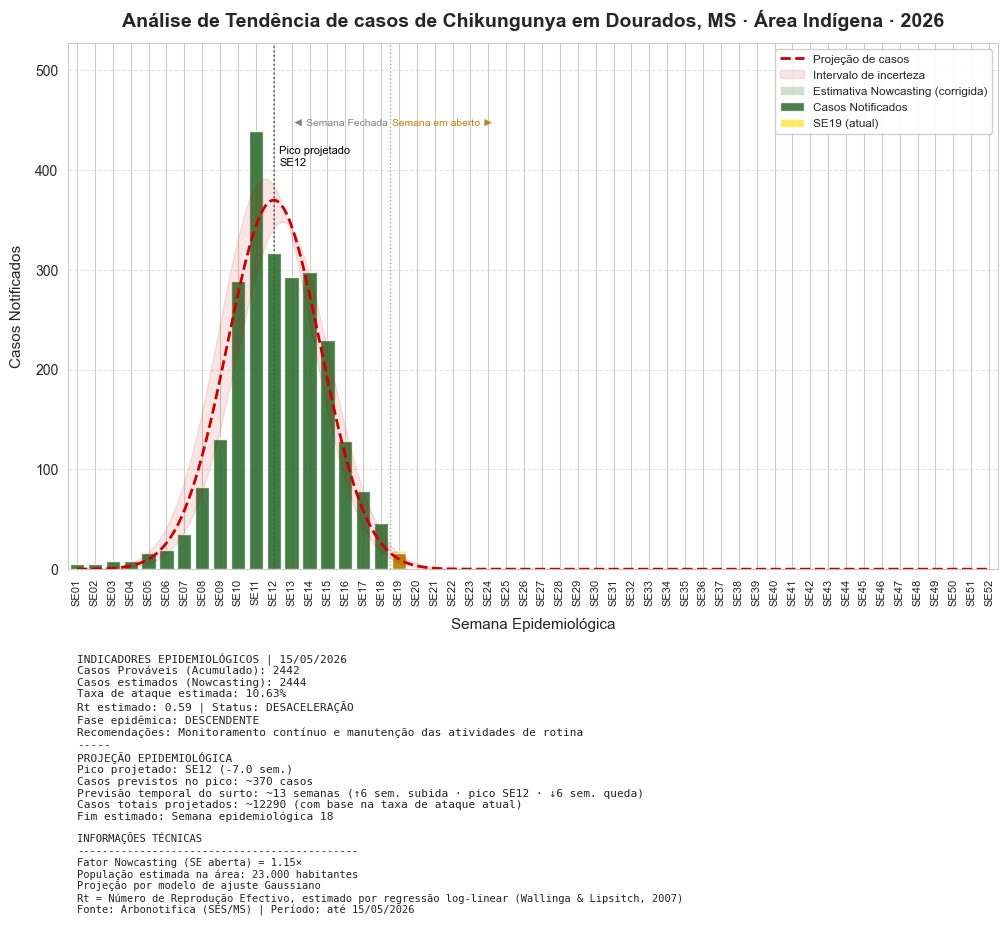

In [25]:
# 1. CARREGAMENTO DOS DADOS
data_analise = datetime.now().strftime("%d/%m/%Y")

df_indigena['SE'] = pd.to_numeric(df_indigena['SE'], errors='coerce')
df_indigena = df_indigena.dropna(subset=['SE'])

df_indigena = df_indigena.dropna(subset=['Semana Epidemiológica'])
df_indigena = df_indigena[~df_indigena['Semana Epidemiológica'].str.contains('53ª', na=False)]

# 2. AGRUPAMENTO E ORDENAÇÃO
contagem = df_indigena['SE'].value_counts().reset_index()
contagem.columns = ['num_semana', 'casos_brutos']

contagem = contagem.sort_values(by='num_semana').reset_index(drop=True)
contagem['tempo'] = contagem['num_semana']

N_SEMANAS = len(contagem)
SE_ATUAL  = contagem['num_semana'].iloc[-1]   # última SE (em aberto)
SE_FECHADAS = N_SEMANAS - 1                   # SE01 a SE13

# 3. NOWCASTING — FATOR EMPÍRICO BASEADO NA SÉRIE HISTÓRICA
dia_da_semana = datetime.now().weekday()
DIA_ATUAL_NA_SEMANA = (dia_da_semana + 2) % 7
if DIA_ATUAL_NA_SEMANA == 0: DIA_ATUAL_NA_SEMANA = 7

# Fração da semana já transcorrida
fracao_semana = DIA_ATUAL_NA_SEMANA / 7.0

FATOR_ATRASO_SINAN = 1.05   # fator empírico médio considerando 1 dia de atraso de notificação

# TABELA DE REFERÊNCIA (FATOR_ATRASO_SINAN):
# 1d: 1.05 | 5d: 1.20 (Urbana) | 7d: 1.30 | 10d: 1.45 (Indígena)
# 15d: 1.65 | 21d: 1.90 | 30d: 2.20 | 60d: 3.00

fator_se_atual = (1 / fracao_semana) * FATOR_ATRASO_SINAN

# LIMITADOR (CAP): Garante que a SE atual não seja bizarramente maior que a anterior
fator_se_atual = min(fator_se_atual, 1.15) # Limite máximo de 60% de acréscimo sobre o parcial

FATOR_SE_ANTERIOR_1 = 1.00 #1.12   # SE13: 12% de subnotificação residual
FATOR_SE_ANTERIOR_2 = 1.00 #1.03   # SE12: 3% de subnotificação residual

fatores_correcao = {
    N_SEMANAS - 1: fator_se_atual,       # SE14 (em aberto)
    N_SEMANAS - 2: FATOR_SE_ANTERIOR_1,  # SE13
    N_SEMANAS - 3: FATOR_SE_ANTERIOR_2,  # SE12
}

contagem['casos_corrigidos'] = contagem['casos_brutos'].astype(float)
for idx, fator in fatores_correcao.items():
    if 0 <= idx < N_SEMANAS:
        contagem.loc[idx, 'casos_corrigidos'] = (
            contagem.loc[idx, 'casos_brutos'] * fator
        )

df_final = contagem.copy()

# 4. ESTIMATIVA DO Rt — MÉTODO WALLINGA-LIPSITCH (JANELA DESLIZANTE)
# Referência: Wallinga & Lipsitch (2007), Proc R Soc B.
# Rt = exp(r * Ts), onde:
#   r  = taxa de crescimento instantânea (regressão log-linear)
#   Ts = intervalo serial médio de Chikungunya ≈ 7 dias (1 semana)
#        (Nishiura et al. 2010; Yakob & Clements 2013)
# Usamos janela de 4 semanas sobre os casos CORRIGIDOS para estabilizar r.
INTERVALO_SERIAL_SEMANAS = 1.0   
JANELA_RT = min(4, SE_FECHADAS)  
y_janela = df_final['casos_corrigidos'].values[-(JANELA_RT + 1):-1] 
x_janela = np.arange(len(y_janela), dtype=float)
y_log = np.log(np.maximum(y_janela, 0.1))
slope, intercept, r_value, p_value, std_err = linregress(x_janela, y_log)
taxa_crescimento_r = slope
Rt = np.exp(taxa_crescimento_r * INTERVALO_SERIAL_SEMANAS)

# Taxa de crescimento semanal (razão simples, para exibição)
razao_crescimento = (df_final['casos_corrigidos'].iloc[-2] /
                     df_final['casos_corrigidos'].iloc[-3]
                     if df_final['casos_corrigidos'].iloc[-3] > 0 else 1.0)

# 5. PROJEÇÃO GAUSSIANA
CENARIO = 'indigena'
POPULACAO = 220_367 if CENARIO == 'urbana' else 23_000
TAXA_ATAQUE_HISTORICA = 0.51 if CENARIO == 'urbana' else 7.02

# 1. Identificar o pico real observado na série
indice_pico_obs = np.argmax(df_final['casos_corrigidos'].values)
se_pico_observado = float(df_final['tempo'].iloc[indice_pico_obs])
valor_pico_observado = df_final['casos_corrigidos'].max()

# 2. CÁLCULO DA TAXA DE ATAQUE EM TEMPO REAL (DINÂMICA)
casos_acumulados_corrigidos = df_final['casos_corrigidos'].sum()
taxa_ataque_notificada = (casos_acumulados_corrigidos / POPULACAO) * 100

# O 'Teto' do modelo agora é o maior valor entre o histórico e o atual com margem
# Isso permite que o modelo acompanhe surtos que superam as médias históricas
TAXA_ATAQUE_MODELO = max(TAXA_ATAQUE_HISTORICA, taxa_ataque_notificada * 2.0)
CASOS_ESPERADOS_TOTAL = (TAXA_ATAQUE_MODELO / 100) * POPULACAO

# AJUSTE 1: Teto dinâmico mais folgado para Rt alto
TAXA_ATAQUE_MODELO = max(TAXA_ATAQUE_HISTORICA, taxa_ataque_notificada * 2.5)
CASOS_ESPERADOS_TOTAL = (TAXA_ATAQUE_MODELO / 100) * POPULACAO

def modelo_gaussiano(x, amplitude, x0, sigma):
    return amplitude * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

# AJUSTE 2: Incluímos a SE atual no ajuste para a curva "sentir" o peso da barra amarela
y_fit = df_final['casos_corrigidos'].values
x_fit = df_final['tempo'].values

# 2. Lógica Adaptativa de Fase
if Rt < 0.95:  # Confirmada a descida
    fase_texto = "DESCENDENTE"
    em_ascensao = False
    # LIBERDADE PARA O PICO VOLTAR: x0 pode estar entre o início e a semana atual
    x0_min, x0_max = 11.0, 12.0
    x0_p0 = 12.0
    #x0_min, x0_max = 1.0, float(SE_ATUAL + 1)
    #x0_p0 = se_pico_observado
    
    # AJUSTE DA AMPLITUDE: Não forçamos mais a curva a ser maior que a SE atual, 
    # mas sim a respeitar o tamanho do pico que já passou.
    amplitude_min = valor_pico_observado * 0.8
    amplitude_max = valor_pico_observado * 1.2
else:
    fase_texto = "ASCENDENTE"
    em_ascensao = True
    x0_min, x0_max = float(SE_ATUAL), float(SE_ATUAL + 10)
    x0_p0 = SE_ATUAL + 3
    amplitude_min = max(df_final['casos_corrigidos']) * 1.1
    amplitude_max = 40000

# 3. Ajuste do Sigma (Largura da curva)
sigma_min, sigma_max = 2.0, 7.0
sigma_p0 = 4.0

# 4. Execução do Ajuste (Garantindo que y_fit use toda a série disponível)
y_fit = df_final['casos_corrigidos'].values
x_fit = df_final['tempo'].values

try:
    popt, pcov = curve_fit(
        modelo_gaussiano, x_fit, y_fit,
        p0=[valor_pico_observado, x0_p0, sigma_p0],
        bounds=([amplitude_min, x0_min, sigma_min], [amplitude_max, x0_max, sigma_max]),
        maxfev=50000
    )
    amplitude_fit, x0_fit, sigma_fit = popt
    
    # Projeção e Incerteza
    x_proj = np.linspace(1, 52, 500)
    y_proj = modelo_gaussiano(x_proj, *popt)
    
    # Cálculo das sombras de incerteza (usando desvio padrão do ajuste)
    perr = np.sqrt(np.diag(pcov))
    y_proj_sup = modelo_gaussiano(x_proj, amplitude_fit + perr[0], x0_fit - 0.5, sigma_fit)
    y_proj_inf = modelo_gaussiano(x_proj, max(amplitude_fit - perr[0], 0), x0_fit + 0.5, sigma_fit)
      
    # --- CÁLCULOS TÉCNICOS ---
    LIMIAR_SURTO = 0.05
    distancia_pico = x0_fit - SE_ATUAL
    casos_pico_estimado = amplitude_fit  
    fator_duracao = np.sqrt(2 * np.log(1 / LIMIAR_SURTO))
    se_inicio_surto = x0_fit - sigma_fit * fator_duracao
    se_fim_surto = x0_fit + sigma_fit * fator_duracao
    duracao_total = se_fim_surto - se_inicio_surto
    duracao_subida = x0_fit - se_inicio_surto
    duracao_queda = se_fim_surto - x0_fit
    
    ajuste_ok = True
except:
    ajuste_ok = False

# 6. CLASSIFICAÇÃO DO CENÁRIO EPIDEMIOLÓGICO
if Rt > 1.2:
    status_rt    = "ALTA"
    cor_status   = "#CC0000"
elif Rt > 1.0:
    status_rt    = "EM CRESCIMENTO"
    cor_status   = "#FF6600"
elif Rt > 0.8:
    status_rt    = "ESTABILIDADE"
    cor_status   = "#E6A817"
else:
    status_rt    = "DESACELERAÇÃO"
    cor_status   = "#2E8B57"

# DESDOBRAMENTOS
if Rt > 1.2:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 1.0:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 0.8:
    recomendação = "Manutenção das atividades de controle vetorial"
else:
    recomendação = "Monitoramento contínuo e manutenção das atividades de rotina"

# 7. VISUALIZAÇÃO
fig = plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Layout: gráfico principal (topo) + rodapé com indicadores
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

labels_ano = [f"SE{str(i).zfill(2)}" for i in range(1, 53)]

# --- Barras ---
barras_corrigidas = ax.bar(
    df_final['num_semana'],
    df_final['casos_corrigidos'],
    color='#8FBC8F', alpha=0.45,
    label='Estimativa Nowcasting (corrigida)',
    zorder=2)
barras_brutas = ax.bar(
    df_final['num_semana'],
    df_final['casos_brutos'],
    color='#2D6A2D', alpha=0.85,
    label='Casos Notificados',
    zorder=3)

# Destaque visual para a semana em aberto
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_corrigidos'].iloc[-1],
    color='#FFD700', alpha=0.6,
    label=f'SE{SE_ATUAL} (atual)',
    zorder=4)
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_brutos'].iloc[-1],
    color='#B8860B', alpha=0.9,
    zorder=5)

# --- Linha de Projeção ---
if ajuste_ok:
    ax.plot(
        x_proj, y_proj,
        color="#CC0000", linestyle='--', linewidth=2,
        label='Projeção de casos',
        zorder=6)
    ax.fill_between(
        x_proj, y_proj_inf, y_proj_sup,
        color="#CC0000", alpha=0.10,
        label='Intervalo de incerteza',
        zorder=5)
    # Marcador do pico projetado
    ax.axvline(x=x0_fit, color="#000000", linestyle=':', linewidth=1.2, alpha=0.6)
    ax.text(x0_fit + 0.3, ax.get_ylim()[1] * 0.92,
            f'Pico projetado\nSE{x0_fit:.0f}',
            fontsize=8, color="#000000", va='top')

# Linha vertical separando semanas fechadas da em aberto
ax.axvline(x=SE_ATUAL - 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(SE_ATUAL - 0.6, ax.get_ylim()[1] * 0.98,
        '◄ Semana Fechada', fontsize=7.5, color='gray', ha='right', va='top')
ax.text(SE_ATUAL - 0.4, ax.get_ylim()[1] * 0.98,
        'Semana em aberto ►', fontsize=7.5, color='#B8860B', ha='left', va='top')

# --- Formatação do eixo ---
ax.set_title(
    'Análise de Tendência de casos de Chikungunya em Dourados, MS · Área Indígena · 2026',
    fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Semana Epidemiológica', fontsize=11, labelpad=8)
ax.set_ylabel('Casos Notificados', fontsize=11, labelpad=8)
ax.set_xticks(range(1, 53))
ax.set_xticklabels(labels_ano, rotation=90, fontsize=8)
ax.set_xlim(0.5, 52.5)
ax.set_ylim(bottom=0, top=max(df_final['casos_brutos'].max() * 1.2, 10))
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 8. RODAPÉ COM INDICADORES E NOTAS TÉCNICAS
ax_rodape = fig.add_subplot(gs[1])
ax_rodape.axis('off')

# Box de indicadores — lado esquerdo
# Box de indicadores — lado esquerdo
indicadores = (
    f"INDICADORES EPIDEMIOLÓGICOS | {data_analise}\n"
    f"Casos Prováveis (Acumulado): {int(df_final['casos_brutos'].sum())}\n"
    f"Casos estimados (Nowcasting): {int(casos_acumulados_corrigidos)}\n"
    f"Taxa de ataque estimada: {taxa_ataque_notificada:.2f}%\n"
    f"Rt estimado: {Rt:.2f} | Status: {status_rt}\n"
    f"Fase epidêmica: {fase_texto}\n"
    f"Recomendações: {recomendação}\n"
    "-----")

if ajuste_ok:
    indicadores += (
        f"\nPROJEÇÃO EPIDEMIOLÓGICA\n"
        f"Pico projetado: SE{x0_fit:.0f} ({distancia_pico:+.1f} sem.)\n"
        f"Casos previstos no pico: ~{casos_pico_estimado:.0f} casos\n"
        f"Previsão temporal do surto: ~{duracao_total:.0f} semanas "
        f"(↑{duracao_subida:.0f} sem. subida · pico SE{x0_fit:.0f} · ↓{duracao_queda:.0f} sem. queda)\n"
        f"Casos totais projetados: ~{casos_totais_proj:.0f} (com base na taxa de ataque atual)\n"
        f"Fim estimado: Semana epidemiológica {se_fim_surto:.0f}\n")

ax_rodape.text(
    0.01, 0.1, indicadores,
    transform=ax_rodape.transAxes,
    fontsize=8, family='monospace', color='#222222',
    va='top', ha='left')

# Notas técnicas — lado direito
notas = (
    "INFORMAÇÕES TÉCNICAS\n"
    "---------------------------------------------\n"
    f"Fator Nowcasting (SE aberta) = {fator_se_atual:.2f}×\n"
    f"População estimada na área: 23.000 habitantes\n"
    f"Projeção por modelo de ajuste Gaussiano\n"
    f"Rt = Número de Reprodução Efectivo, estimado por regressão log-linear (Wallinga & Lipsitch, 2007)\n"
    f"Fonte: Arbonotifica (SES/MS) | Período: até 15/05/2026")

# Outras opções de fonte para o rodapé:
ax_rodape.text(
    0.01, -2.3, notas,
    transform=ax_rodape.transAxes, fontsize=7.5,
    family='monospace',  # troque para 'Consolas', 'Courier New', etc. se preferir
    color='#222222',
    va='top', ha='left')

data_analise = datetime.now().strftime("%d/%m/%Y")

# 9. RESUMO NO CONSOLE
print(f"ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA URBANA ({data_analise})")

print(f"Semanas no dataset: {N_SEMANAS} (SE01–SE{SE_ATUAL})")
print(f"Semanas fechadas  : {SE_FECHADAS}")
print(f"\nFator nowcasting SE{SE_ATUAL}: {fator_se_atual:.2f}x (em aberto)")
print(f"Fator nowcasting SE{SE_ATUAL-1}: {FATOR_SE_ANTERIOR_1:.2f}x")
print(f"\nRt (Wallinga-Lipsitch, janela {JANELA_RT} semanas)")
print(f"Taxa de crescimento (r): {taxa_crescimento_r:+.4f} por semana")
print(f"Rt estimado            : {Rt:.2f}")
print(f"\nTotal esperado de casos (taxa de ataque): {CASOS_ESPERADOS_TOTAL:.0f}")
print(f"Amplitude máxima permitida (pico/semana): {amplitude_max:.0f} casos")
print(f"\nFase epidêmica detectada: {fase_texto}")
print()
print(f"Casos notificados      : {int(df_final['casos_brutos'].sum())}")
print(f"Casos estimados (now.) : {int(df_final['casos_corrigidos'].sum())}")
print(f"Rt ({JANELA_RT} sem.)            : {Rt:.2f}")
print(f"Status                 : {status_rt}")
print(f"Fase epidêmica         : {fase_texto}")
if ajuste_ok:
    print(f"Pico projetado         : SE{x0_fit:.0f} (em {distancia_pico:+.1f} semanas)")
    print(f"Casos no pico          : ~{casos_pico_estimado:.0f} casos/semana")
    print(f"Duração total do surto : ~{duracao_total:.0f} semanas")
    print(f"↑ Subida               : ~{duracao_subida:.0f} semanas (até SE{x0_fit:.0f})")
    print(f"↓ Queda                : ~{duracao_queda:.0f} semanas (SE{x0_fit:.0f} → SE{se_fim_surto:.0f})")
    print(f"Fim estimado do surto  : SE{se_fim_surto:.0f}")
    print(f"Casos totais projetados: ~{casos_totais_proj:.0f}")

##### Algoritmo desenvolvido por Dengue Brazil